## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

###  Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [5]:
df.isnull().sum()

gender                      0
race_ethnicity              0
parental_level_education    0
lunch                       0
test_preparation_course     0
math_score                  0
reading_score               0
writing_score               0
dtype: int64

#### There is no missing values

In [6]:
df.duplicated().sum()

0

#### There is no duplicate value

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    1000 non-null   object
 1   race_ethnicity            1000 non-null   object
 2   parental_level_education  1000 non-null   object
 3   lunch                     1000 non-null   object
 4   test_preparation_course   1000 non-null   object
 5   math_score                1000 non-null   int64 
 6   reading_score             1000 non-null   int64 
 7   writing_score             1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()    # unique values in each column

gender                       2
race_ethnicity               5
parental_level_education     6
lunch                        2
test_preparation_course      2
math_score                  81
reading_score               72
writing_score               77
dtype: int64

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### Exploring the data

In [10]:
for col in df.columns:
    if df[col].dtype=='object':
        print(f"Categories in {col} Variable: {list(df[col].unique())}")

Categories in gender Variable: ['female', 'male']
Categories in race_ethnicity Variable: ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in parental_level_education Variable: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in lunch Variable: ['standard', 'free/reduced']
Categories in test_preparation_course Variable: ['none', 'completed']


In [11]:
num_features=[feature for feature in df.columns if df[feature].dtype!='O']
cat_features=[feature for feature in df.columns if df[feature].dtype=='O']

In [12]:
print(num_features)
print(cat_features)

['math_score', 'reading_score', 'writing_score']
['gender', 'race_ethnicity', 'parental_level_education', 'lunch', 'test_preparation_course']


### Adding columns for "Total Score" and "Average"

In [13]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Histogram and kde


<Axes: xlabel='average', ylabel='Count'>

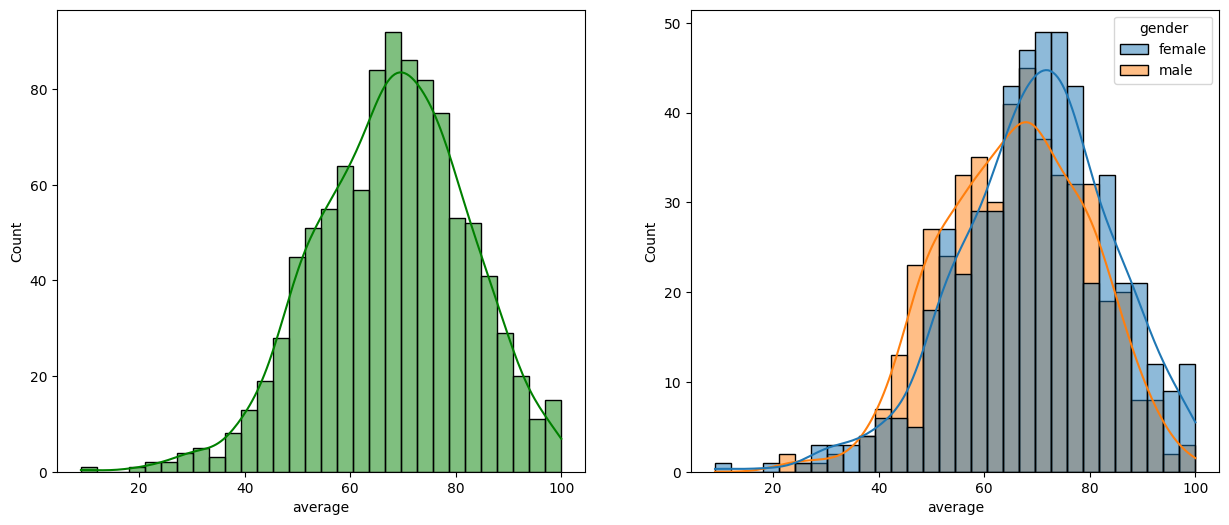

In [14]:
fig,axs=plt.subplots(1,2,figsize=(15,6))
plt.subplot(1,2,1)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='gender')


### hence the feamale student performing well with respect to male 

<Axes: xlabel='average', ylabel='Count'>

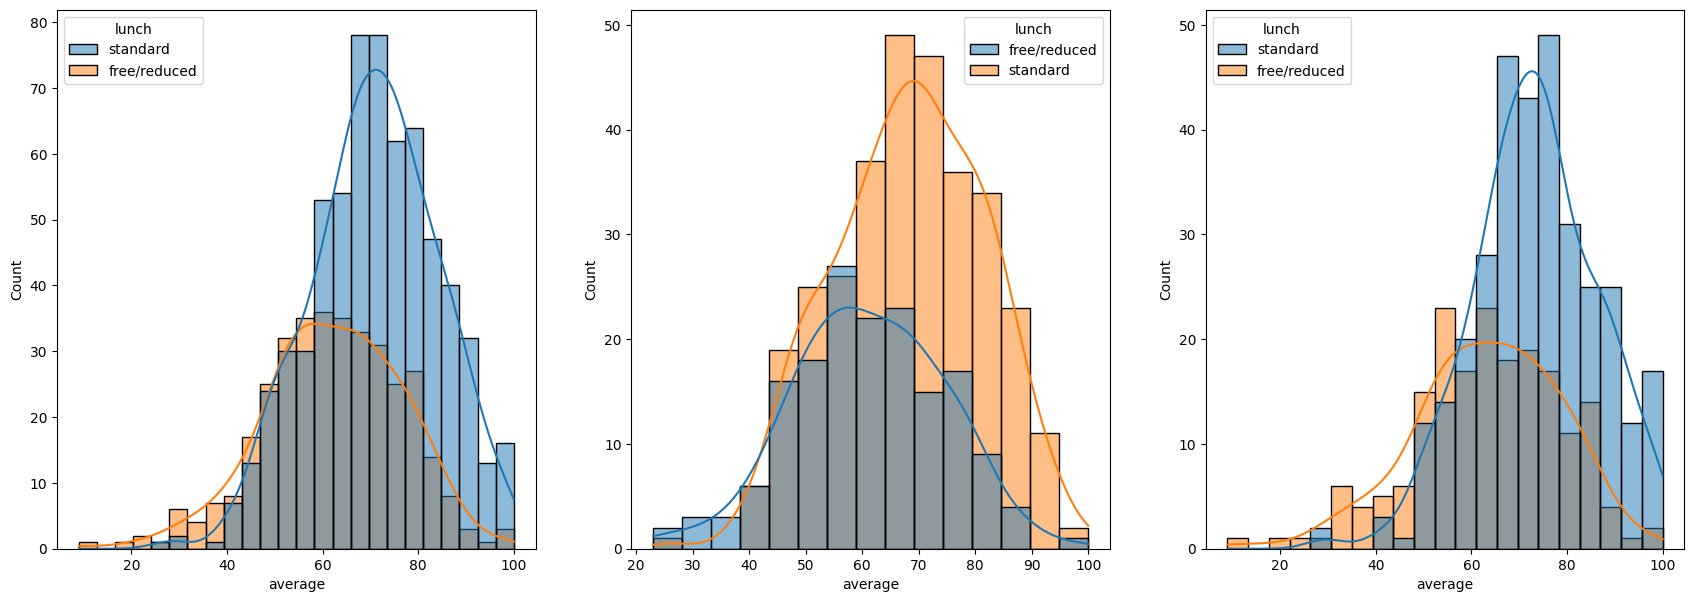

In [15]:
plt.subplots(1,3,figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='female'],x='average',kde=True,hue='lunch')

### student with standard lunch perform well weather male or female  

<Axes: xlabel='average', ylabel='Count'>

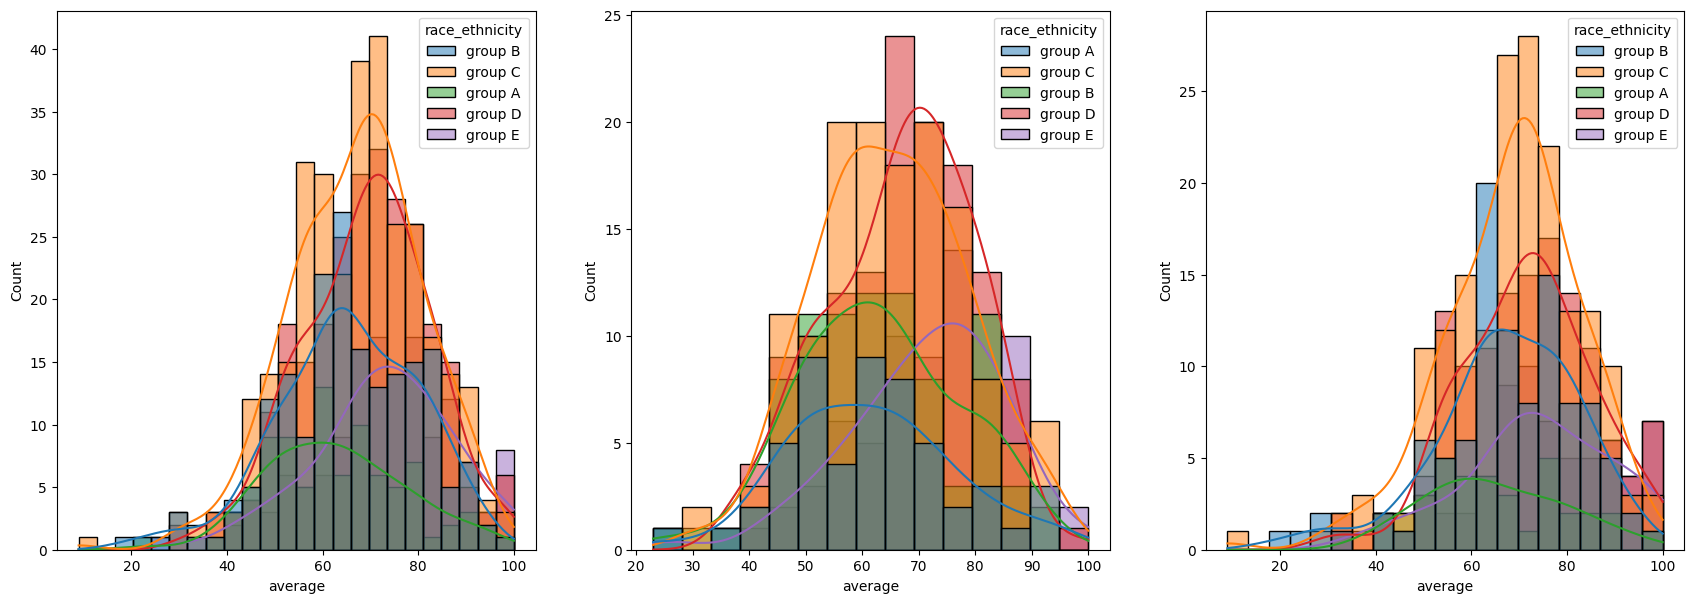

In [16]:
plt.subplots(1,3,figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='female'],x='average',kde=True,hue='race_ethnicity')

### majorly there is no dependence of score on groups

<Axes: xlabel='average', ylabel='Count'>

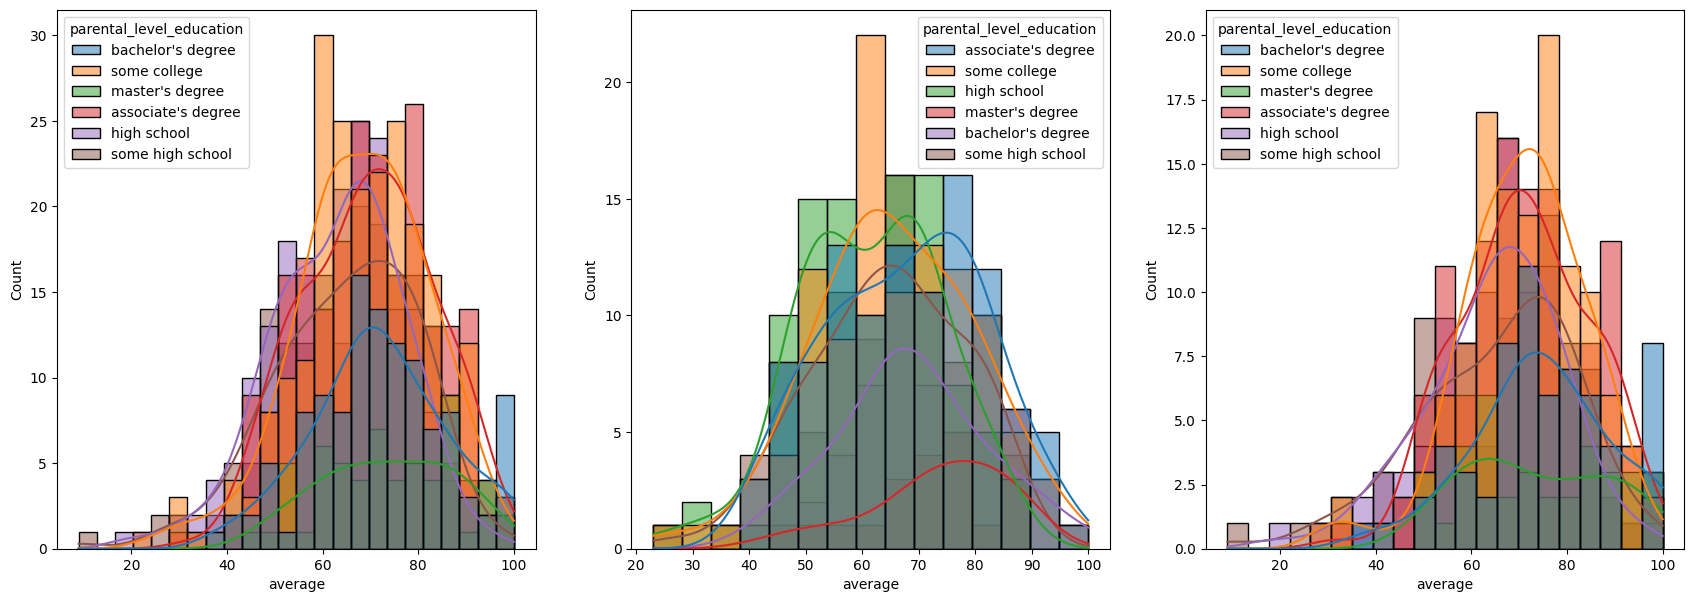

In [17]:

plt.subplots(1,3,figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',kde=True,hue='parental_level_education')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='parental_level_education')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='female'],x='average',kde=True,hue='parental_level_education')

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

<Axes: xlabel='average', ylabel='Count'>

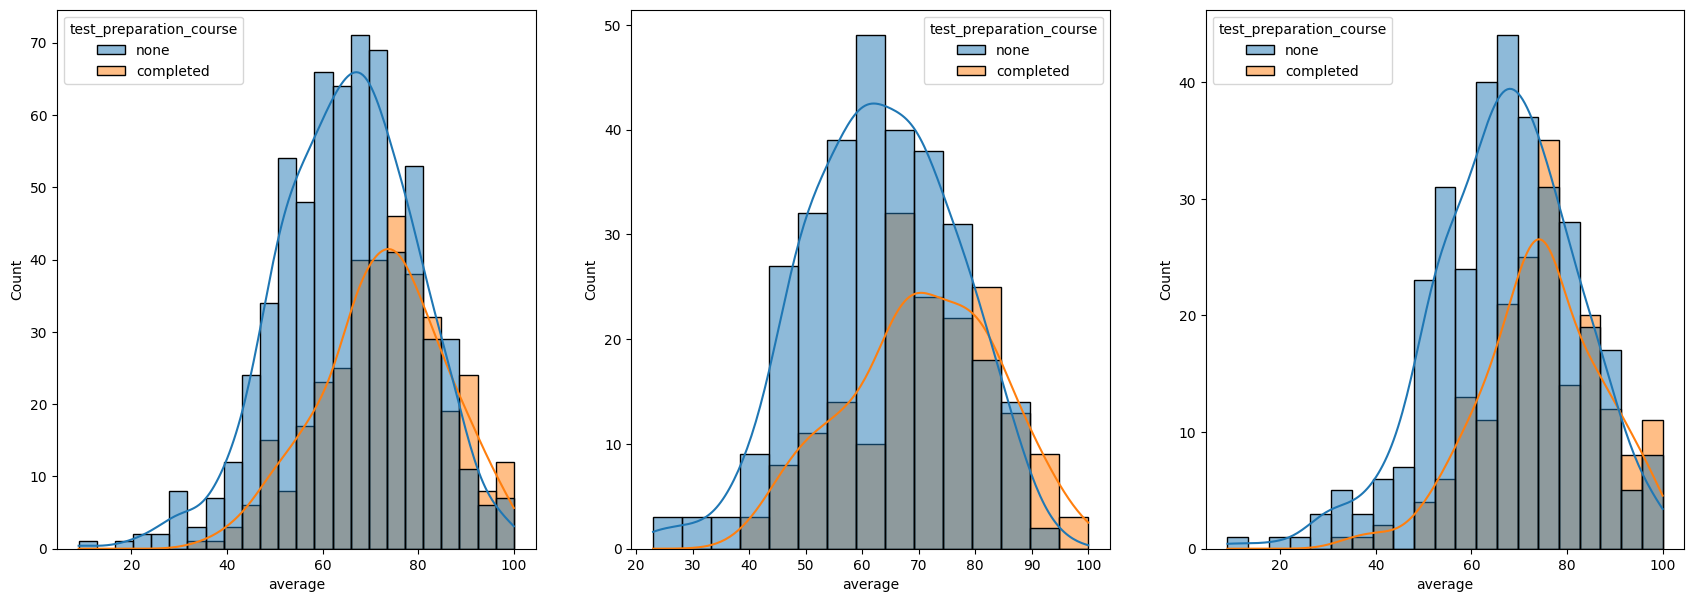

In [18]:

plt.subplots(1,3,figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',kde=True,hue='test_preparation_course')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='test_preparation_course')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='female'],x='average',kde=True,hue='test_preparation_course')

#### Student with completed course perform well either male or female

### Scores of the students in the all subjects

<Axes: xlabel='writing_score'>

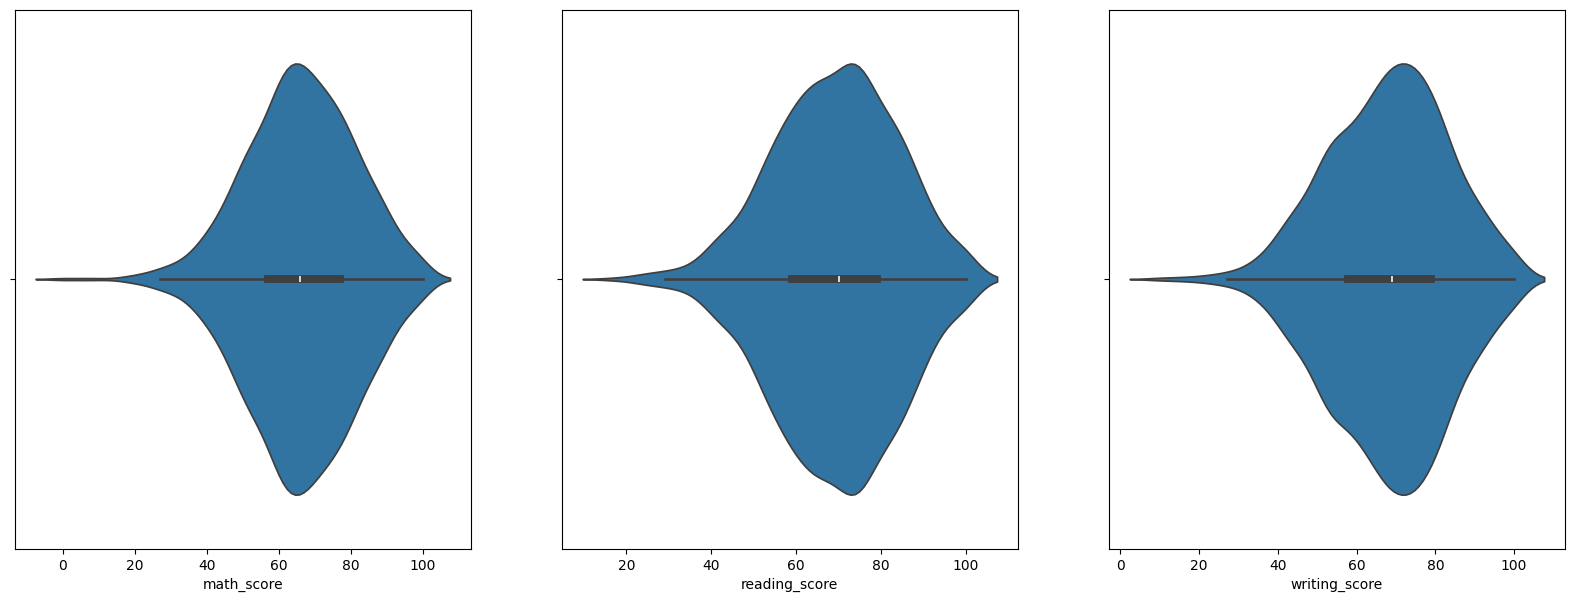

In [19]:
plt.subplots(1,3,figsize=(20,7))
plt.subplot(1,3,1)
sns.violinplot(data=df,x='math_score')
plt.subplot(1,3,2)
sns.violinplot(data=df,x='reading_score')
plt.subplot(1,3,3)
sns.violinplot(data=df,x='writing_score')

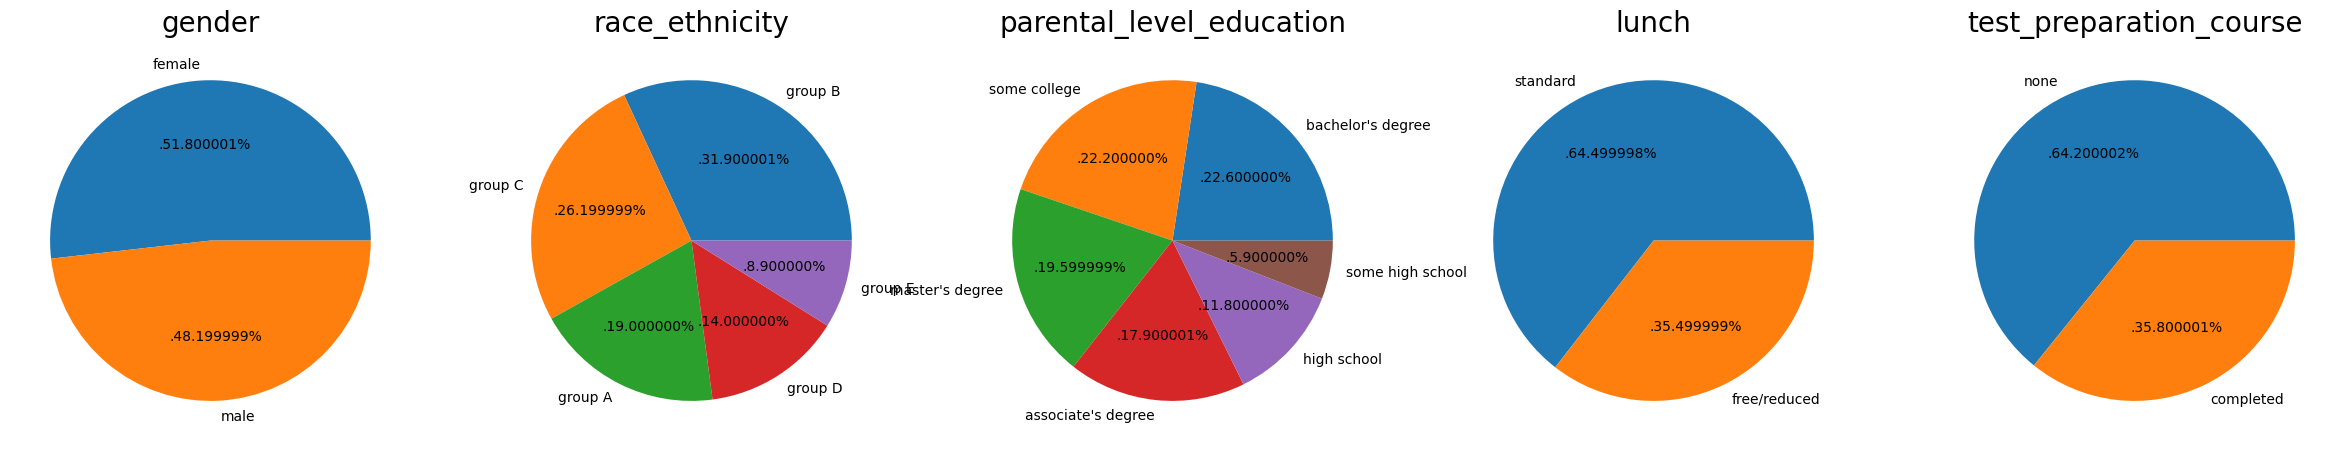

In [20]:
plt.subplots(1,5,figsize=(30,12))
i=1
for col in cat_features:
    plt.subplot(1, 5, i)
    size = df[col].value_counts()
    labels = df[col].unique()
    plt.pie(size,  labels = labels,autopct = '.%2f%%')
    plt.title(f'{col}', fontsize = 20)
    i+=1

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

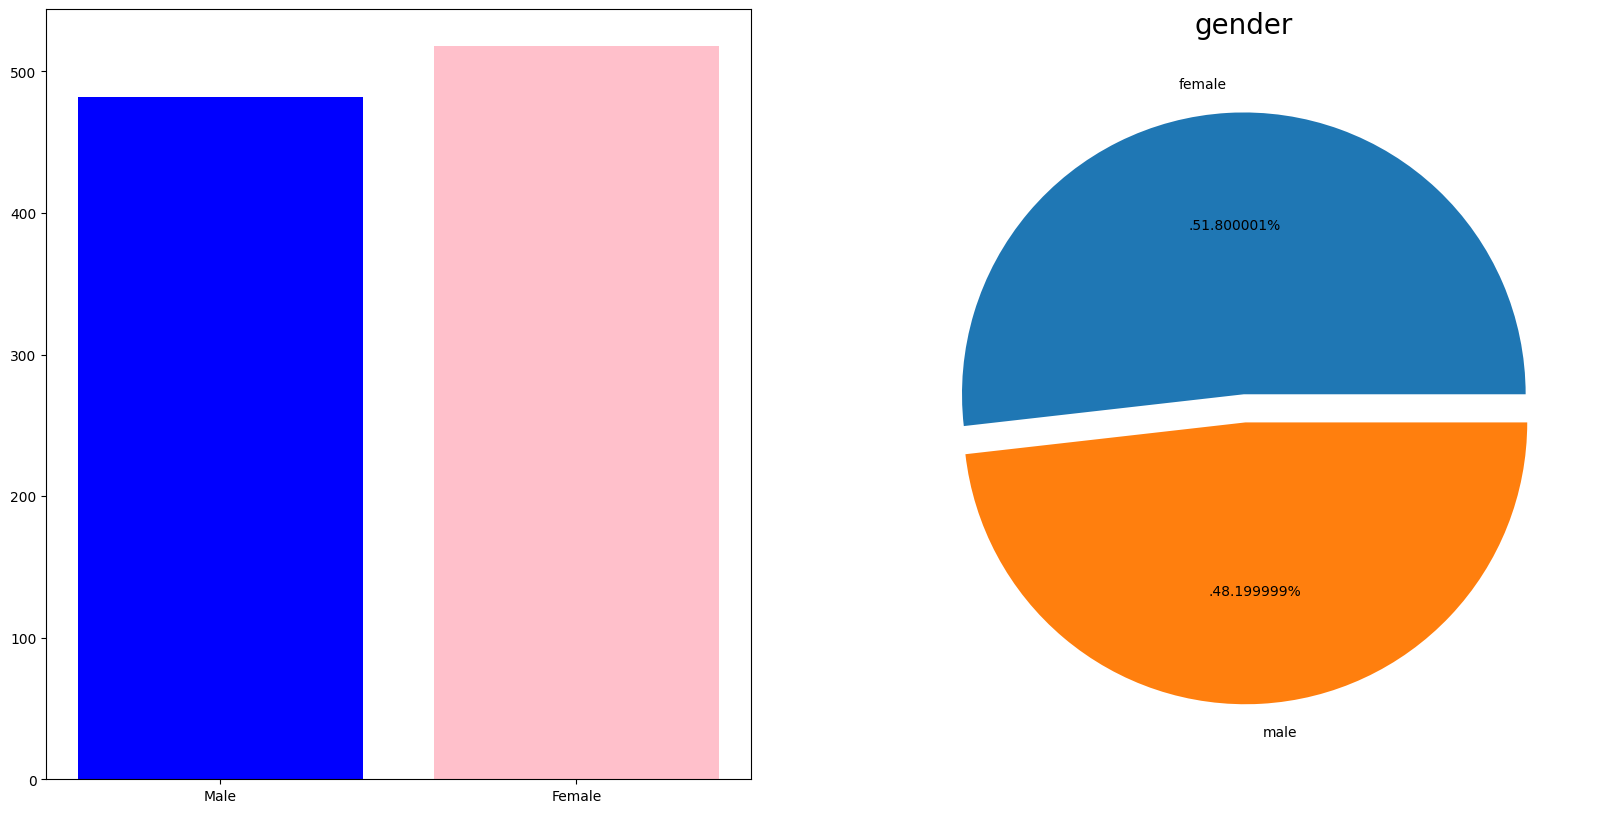

In [21]:
plt.subplots(1, 2, figsize=(20, 10))
male_count = df[df['gender'] == 'male'].shape[0]
female_count = df[df['gender'] == 'female'].shape[0]
plt.subplot(1, 2, 1)
plt.bar(x=['Male', 'Female'], height=[male_count, female_count], color=['blue', 'pink'])

plt.subplot(1, 2, 2)
size = df['gender'].value_counts()
labels = df['gender'].unique()
plt.pie(size,  labels = labels,autopct = '.%2f%%',explode=[0,0.1])
plt.title('gender', fontsize = 20)


plt.show()

In [22]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


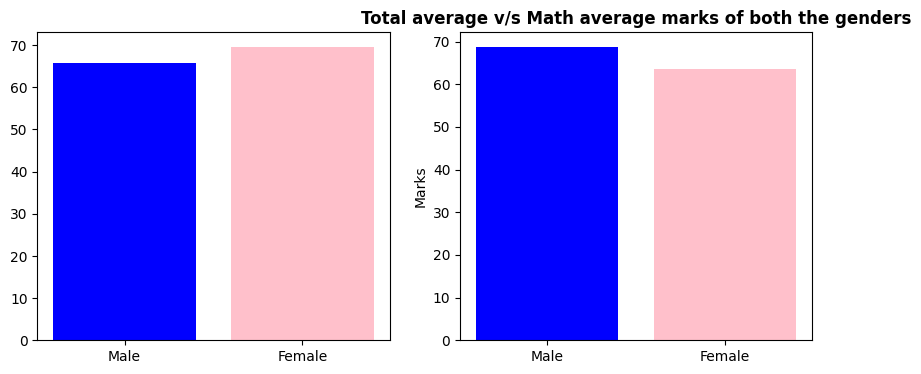

In [24]:
plt.figure(figsize=(10, 4))
female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]
  
plt.subplot(1, 2, 1)
plt.bar(x=['Male', 'Female'], height=[male_scores[0], female_scores[0]], color=['blue', 'pink'])
plt.subplot(1, 2, 2)
plt.bar(x=['Male', 'Female'], height=[male_scores[1], female_scores[1]], color=['blue', 'pink'])
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.show()

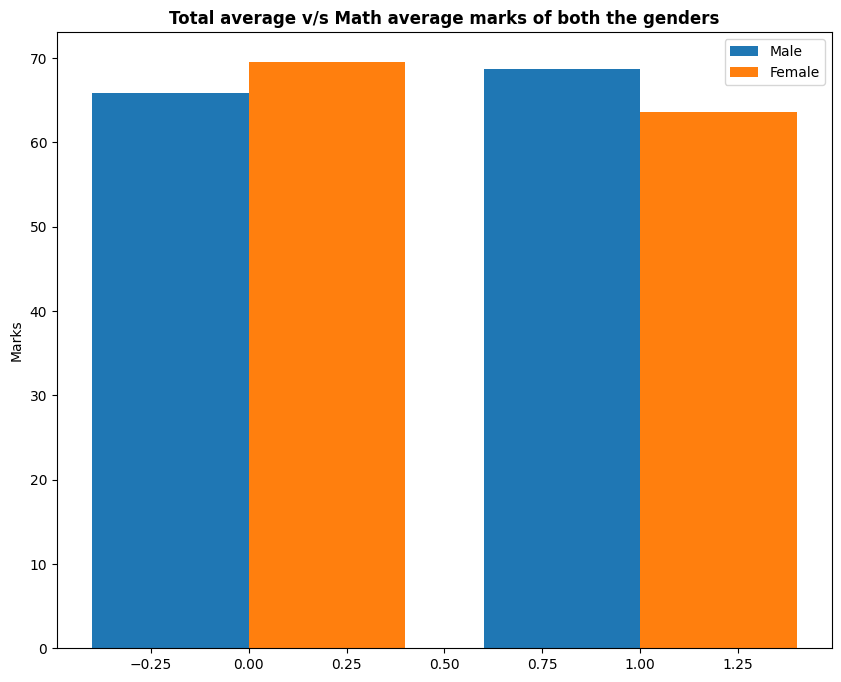

In [25]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']
female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X)) ## [0,1...n] for n labels
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
# plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### CHECKING OUTLIERS

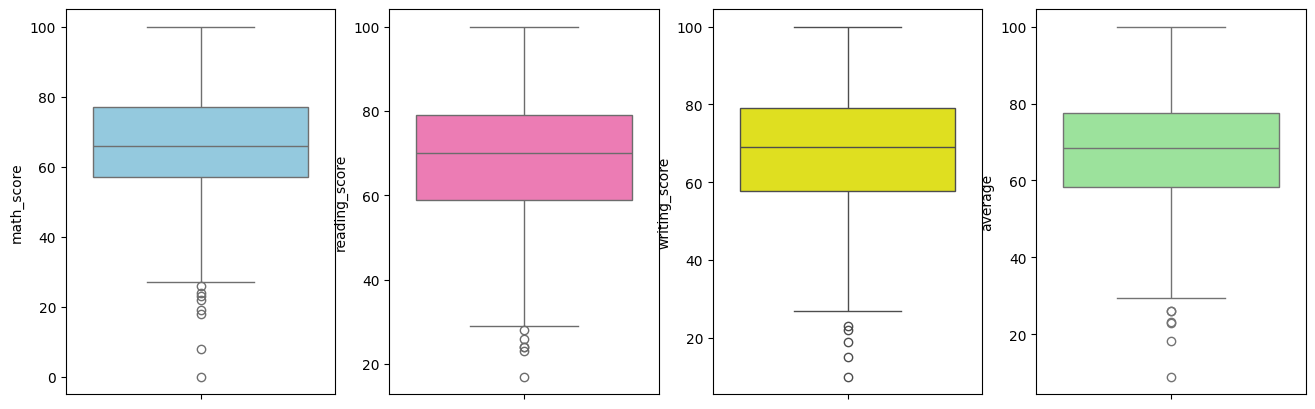

In [26]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### MUTIVARIATE ANALYSIS USING PAIRPLOT

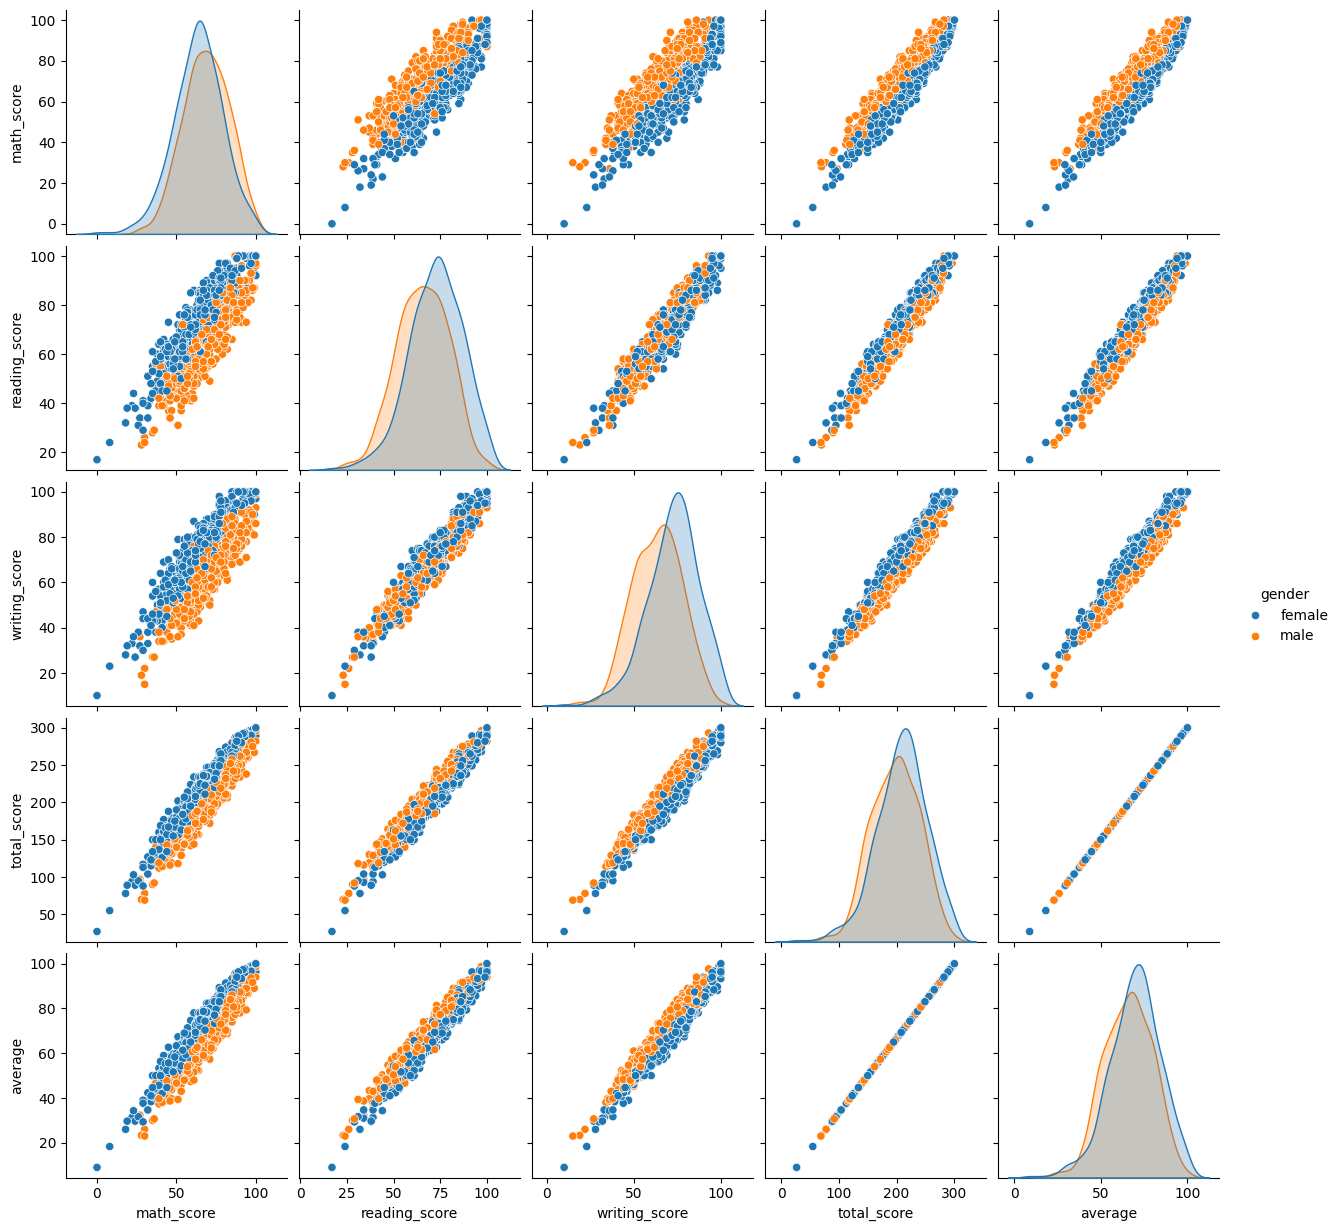

In [27]:
sns.pairplot(df,hue = 'gender')
plt.show()